<a href="https://colab.research.google.com/github/channel1umut-lang/Machine-Learning-Applications/blob/main/0013_KNNClassifierAndRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# bmi_score -> Body Mass Index (standardized)
# blood_pressure_variation -> Fluctuation in systolic blood pressure
# activity_level_index -> Daily activity level (from wearable data, normalized)
# high_risk_flag -> 1 = High health risk, 0 = Low risk

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/12-health_risk_classification.csv')

In [ ]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [ ]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


In [ ]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


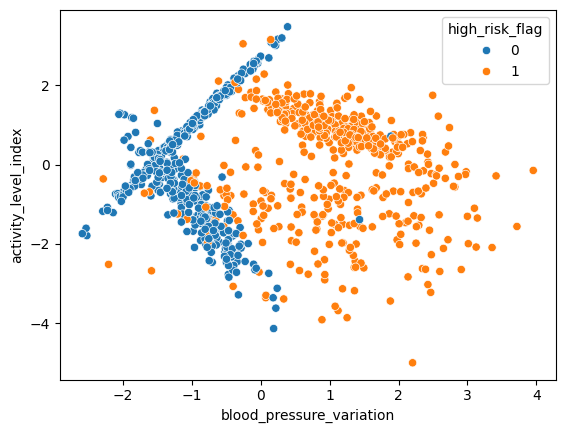

In [ ]:
sns.scatterplot(x=df['blood_pressure_variation'],y=df['activity_level_index'],hue=df['high_risk_flag'])
plt.show()

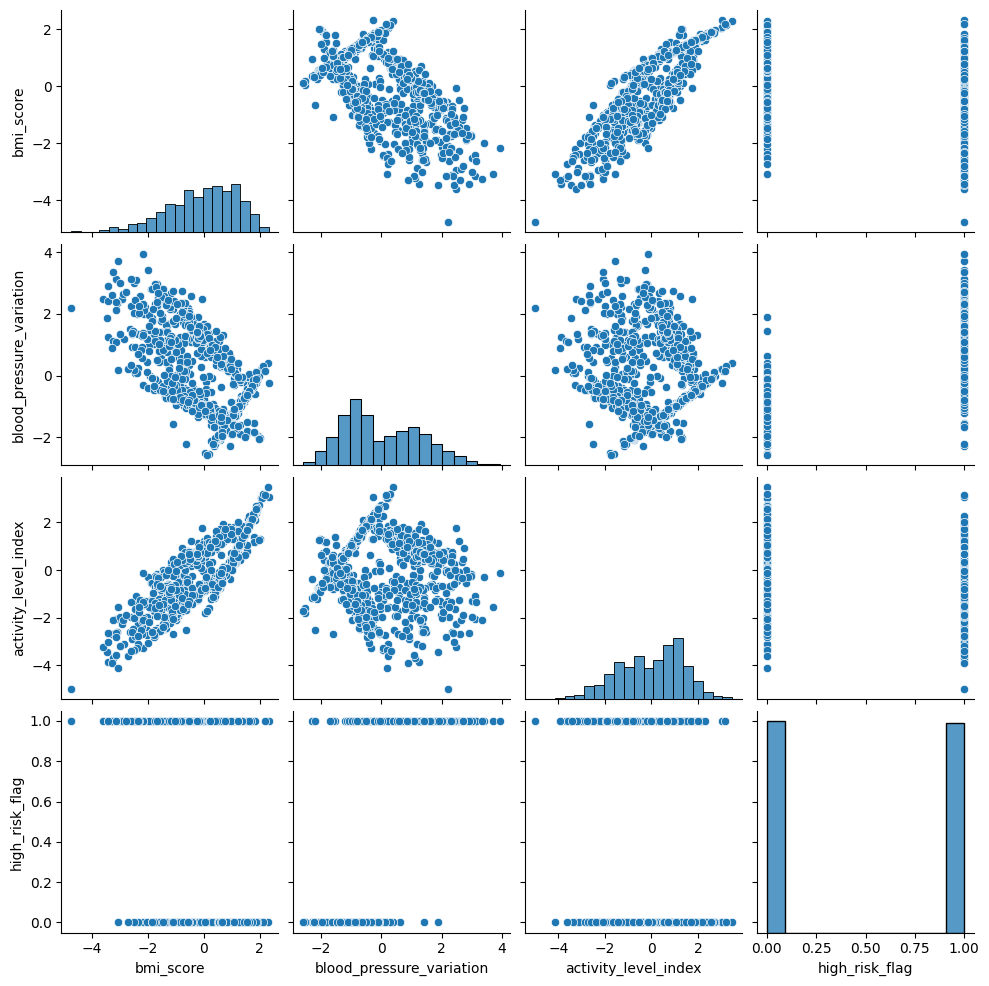

In [ ]:
sns.pairplot(df)
plt.show()


In [ ]:
df['high_risk_flag'].value_counts()

,count
high_risk_flag,
0,502
1,498


In [ ]:
X=df.drop('high_risk_flag',axis=1)
y=df['high_risk_flag']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

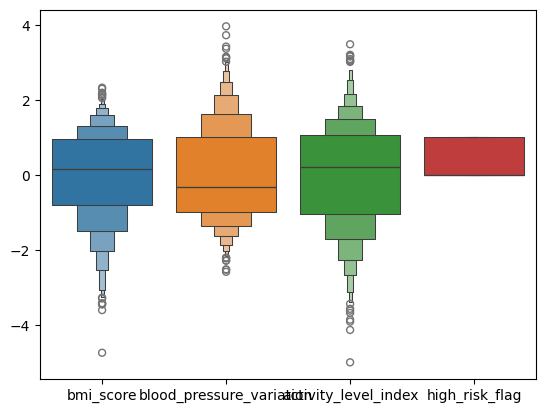

In [ ]:
sns.boxenplot(df)
plt.show()

In [ ]:
# even though data is created for the course and seems scaled i will apply scaler so that
# you won't forget in real life

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='auto') #BURDA NEIGHBOR ONEMLI!!! defaukt deeri de 5 zaten
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred=classifier.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
print("confusion matrix: \n ", confusion_matrix(y_pred,y_test))
print("accuracy score: ", accuracy_score(y_pred,y_test))
print("classification report: ", classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score:  0.952
classification report:                precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [ ]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='kd_tree') # this won't change the overall accuracy but maybe calculation time
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [ ]:
y_pred=classifier.predict(X_test_scaled)
print("confusion matrix: \n ", confusion_matrix(y_pred,y_test))
print("accuracy score: ", accuracy_score(y_pred,y_test))
print("classification report: ", classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score:  0.952
classification report:                precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [ ]:
#what can change the overall accuracy is k number

In [ ]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='auto')
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred=classifier.predict(X_test_scaled)
print("confusion matrix: \n ", confusion_matrix(y_pred,y_test))
print("accuracy score: ", accuracy_score(y_pred,y_test))
print("classification report: ", classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score:  0.952
classification report:                precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [ ]:
# knn can be used for regression as well

In [ ]:
df_reg = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/12-house_energy_regression.csv")

In [ ]:
df_reg

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530
...,...,...,...
995,-0.753965,-0.280675,-33.182365
996,-2.172670,0.847422,-71.059718
997,0.302635,-0.754276,3.260515
998,0.381935,0.430042,42.654703


In [ ]:
# avg_indoor_temp_change -> Change in indoor temperature over the past 24h (°C)
# outdoor_humidity_level -> Relative outdoor humidity (%)
# daily_energy_consumption_kwh -> Energy usage (in kWh) for the household over one day

In [ ]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [ ]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [ ]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


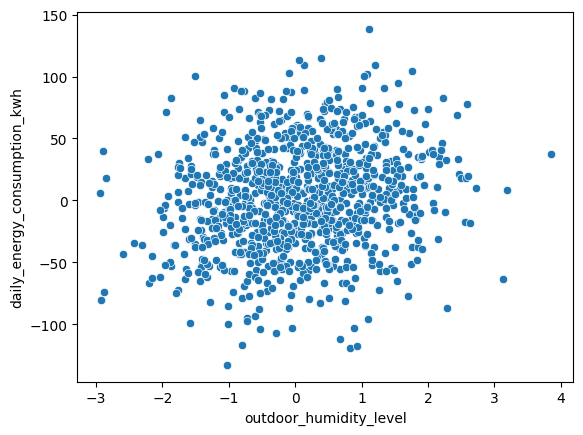

In [ ]:
sns.scatterplot(x=df_reg['outdoor_humidity_level'],y=df_reg['daily_energy_consumption_kwh'])
plt.show()

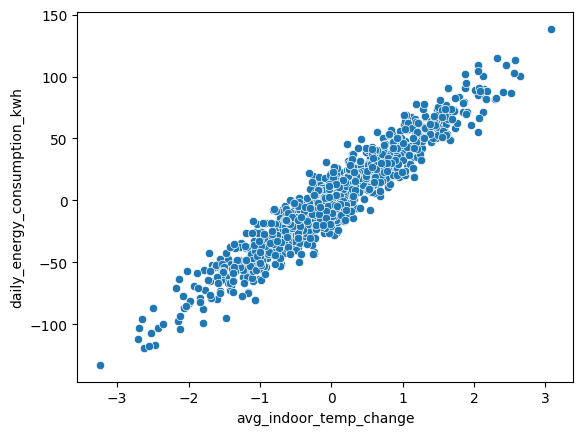

In [ ]:
sns.scatterplot(x=df_reg['avg_indoor_temp_change'],y=df_reg['daily_energy_consumption_kwh'])
plt.show()

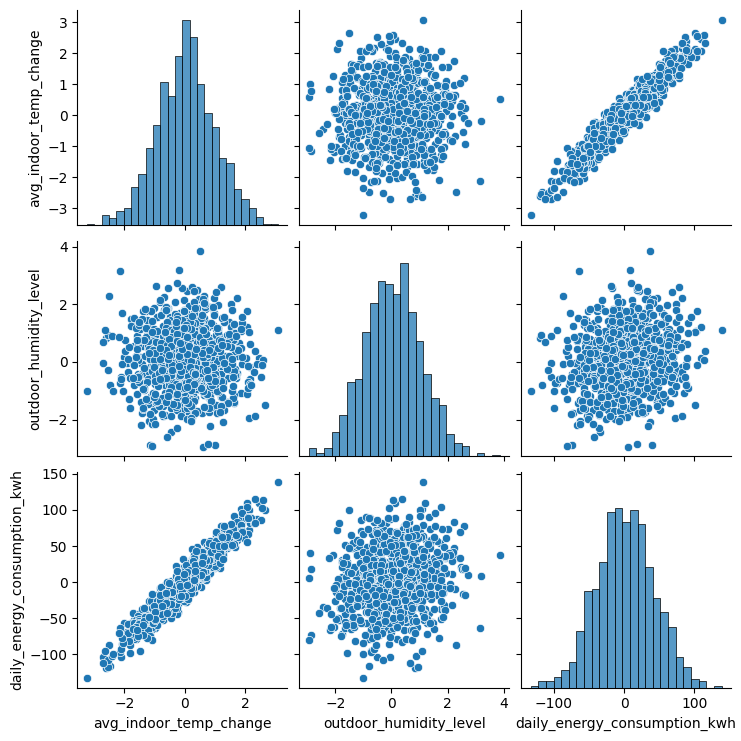

In [ ]:
sns.pairplot(df_reg)
plt.show()


In [ ]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [ ]:
X=df_reg.drop('daily_energy_consumption_kwh',axis=1)
y=df_reg['daily_energy_consumption_kwh']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
regressor=KNeighborsRegressor(n_neighbors=5,algorithm='auto')
regressor.fit(X_train_scaled,y_train) #egitti

KNeighborsRegressor()

In [ ]:
y_pred=regressor.predict(X_test_scaled) #tahminleri test etti

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error #sonuclari karsilastirdi

In [ ]:
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))

r2 score:  0.9152685146562609
mean absolute error:  9.42143518926242
mean squared error:  140.40201685069158


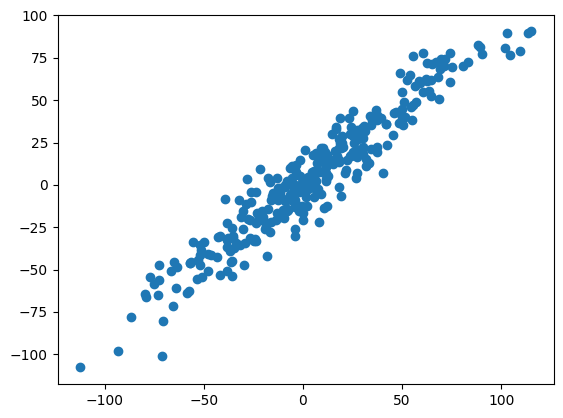

In [ ]:
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
# you can again test with different k values

In [ ]:
regressor=KNeighborsRegressor(n_neighbors=7,algorithm='auto')
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=7)

r2 score:  0.9164863388635838
mean absolute error:  9.331428506491209
mean squared error:  138.3840541750219


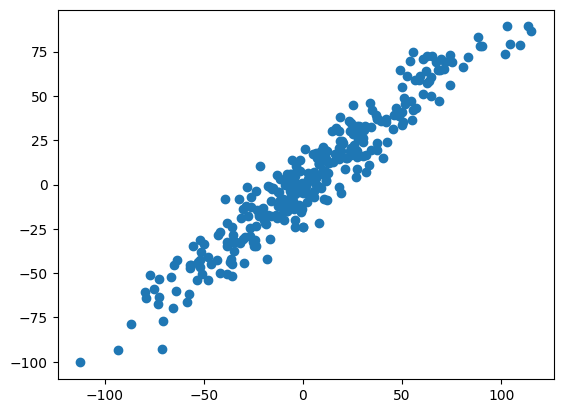

In [ ]:
y_pred=regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
regressor=KNeighborsRegressor(n_neighbors=25,algorithm='auto') # if you exaggerate k values, your metrics will decrease
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=25)

r2 score:  0.9118719343331324
mean absolute error:  9.42127621485675
mean squared error:  146.0302284396658


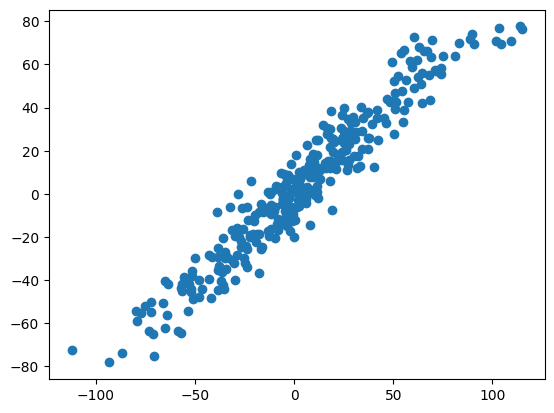

In [ ]:
y_pred=regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()